# Week 4 — Math Intuition for ML
**Intern:** Sankalpa Parajuli | **Program:** AI/ML Internship | **Week 4: Math Intuition for ML + Mini Project**

This notebook builds intuition (not just formulas) for the linear algebra, probability, and calculus
concepts used every day in machine learning: vectors & matrices, dot products, conditional probability
and distributions, derivatives/gradients, and gradient descent as the mechanism models use to "learn".


In [1]:
import numpy as np
import matplotlib.pyplot as plt
np.set_printoptions(precision=3, suppress=True)


## 1. Vectors — data points as arrows

In ML, a data row (e.g. a house's [size, bedrooms, price]) is just a **vector**: a list of numbers
that also has a geometric meaning — a point in space, or an arrow from the origin to that point.


In [2]:
# Two simple 2D vectors
a = np.array([3, 1])
b = np.array([1, 2])

print("a =", a)
print("b =", b)
print("a + b =", a + b)      # element-wise addition -> moves the arrow
print("2 * a =", 2 * a)      # scaling -> stretches the arrow


a = [3 1]
b = [1 2]
a + b = [4 3]
2 * a = [6 2]


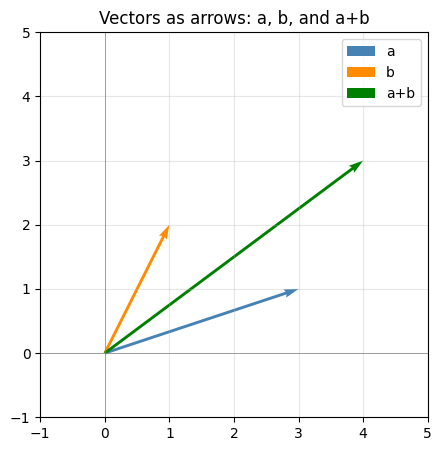

In [3]:
fig, ax = plt.subplots(figsize=(5, 5))
ax.quiver(0, 0, a[0], a[1], angles='xy', scale_units='xy', scale=1, color='steelblue', label='a')
ax.quiver(0, 0, b[0], b[1], angles='xy', scale_units='xy', scale=1, color='darkorange', label='b')
ax.quiver(0, 0, (a+b)[0], (a+b)[1], angles='xy', scale_units='xy', scale=1, color='green', label='a+b')
ax.set_xlim(-1, 5); ax.set_ylim(-1, 5)
ax.axhline(0, color='gray', lw=0.5); ax.axvline(0, color='gray', lw=0.5)
ax.set_title('Vectors as arrows: a, b, and a+b')
ax.legend(); ax.grid(alpha=0.3)
plt.savefig('images/vectors.png', dpi=110, bbox_inches='tight')
plt.show()


**Takeaway:** a feature row in a dataset is a vector. Adding vectors combines their directions;
scaling a vector stretches or shrinks it without changing its direction. This is exactly what happens
when a model multiplies your features by learned weights.


## 2. Dot product — how a model "scores" a data point

The dot product multiplies two vectors element-wise and sums the result. This single operation is the
core of a linear model's prediction: `prediction = weights . features`.


In [4]:
features = np.array([1500, 3])       # [house size (sqft), bedrooms]
weights  = np.array([150, 8000])      # [price per sqft, price per bedroom]

dot = np.dot(features, weights)
print("features . weights =", dot)
print("(this is exactly how a linear regression makes a prediction, before adding a bias term)")


features . weights = 249000
(this is exactly how a linear regression makes a prediction, before adding a bias term)


In [5]:
# Dot product also tells us about the ANGLE between two vectors
def angle_between(u, v):
    cos_theta = np.dot(u, v) / (np.linalg.norm(u) * np.linalg.norm(v))
    return np.degrees(np.arccos(np.clip(cos_theta, -1, 1)))

print("angle between a and b:", round(angle_between(a, b), 1), "degrees")

c = np.array([3, 1])  # same direction as a
print("angle between a and c (same direction):", round(angle_between(a, c), 1), "degrees")

d = np.array([-1, 3])  # roughly opposite-ish direction
print("angle between a and d:", round(angle_between(a, d), 1), "degrees")


angle between a and b: 45.0 degrees
angle between a and c (same direction): 0.0 degrees
angle between a and d: 90.0 degrees


**Takeaway:** a large positive dot product means two vectors point in a similar direction
(their features "agree"); near zero means they're roughly unrelated (perpendicular); negative means
they point in opposite directions. This is the geometric reason dot products show up everywhere from
linear regression to cosine-similarity in NLP.


## 3. Matrices & matrix multiplication — many predictions at once

A matrix is just a stack of vectors — e.g. a whole dataset (rows = samples, columns = features).
Matrix multiplication applies the *same* dot product to every row at once — this is how a model
scores an entire dataset in one operation instead of a loop.


In [6]:
# 4 houses, 2 features each: [size, bedrooms]
X = np.array([
    [1500, 3],
    [1800, 4],
    [1200, 2],
    [2200, 4],
])

w = np.array([150, 8000])   # same weights as before

predictions = X @ w   # matrix-vector multiplication = one dot product per row
print("Predictions for all 4 houses at once:\n", predictions)


Predictions for all 4 houses at once:
 [249000 302000 196000 362000]


In [7]:
# Matrix x Matrix: transforming a whole matrix
M = np.array([[2, 0],
              [0, 3]])   # scales x by 2, y by 3

points = np.array([[1, 1],
                    [2, 1],
                    [1, 2]])

transformed = points @ M
print("Original points:\n", points)
print("Transformed points:\n", transformed)


Original points:
 [[1 1]
 [2 1]
 [1 2]]
Transformed points:
 [[2 3]
 [4 3]
 [2 6]]


**Takeaway:** `X @ w` scoring every row of a dataset in one line is *why* NumPy/ML libraries are
fast — no Python loops, just vectorized linear algebra under the hood.


## 4. Probability basics — conditional probability & distributions

Models constantly reason under uncertainty. Two ideas come up everywhere:
- **Conditional probability**: P(A | B) — how likely A is, *given* we already know B.
- **Distributions**: the overall shape of how values are spread (e.g. Normal, Binomial).


In [8]:
# Conditional probability with a simple deck-of-cards style example
# 52 cards: P(King) vs P(King | card is a Face card)
p_king = 4/52
p_face = 12/52          # Jack, Queen, King = 12 face cards
p_king_and_face = 4/52  # every King is also a face card

p_king_given_face = p_king_and_face / p_face

print(f"P(King)            = {p_king:.3f}")
print(f"P(King | Face card) = {p_king_given_face:.3f}")
print("--> Knowing it's a face card makes 'King' 3x more likely: this is the whole idea behind")
print("    how models update beliefs (e.g. Naive Bayes) when new evidence/features come in.")


P(King)            = 0.077
P(King | Face card) = 0.333
--> Knowing it's a face card makes 'King' 3x more likely: this is the whole idea behind
    how models update beliefs (e.g. Naive Bayes) when new evidence/features come in.


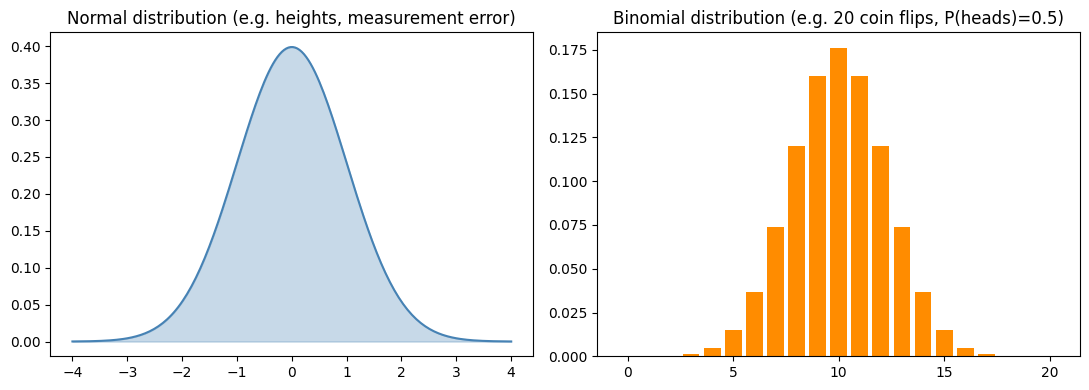

In [9]:
from scipy import stats

x = np.linspace(-4, 4, 200)
normal_pdf = stats.norm.pdf(x, loc=0, scale=1)

n, p = 20, 0.5
k = np.arange(0, n+1)
binom_pmf = stats.binom.pmf(k, n, p)

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
axes[0].plot(x, normal_pdf, color='steelblue')
axes[0].fill_between(x, normal_pdf, alpha=0.3, color='steelblue')
axes[0].set_title('Normal distribution (e.g. heights, measurement error)')

axes[1].bar(k, binom_pmf, color='darkorange')
axes[1].set_title('Binomial distribution (e.g. 20 coin flips, P(heads)=0.5)')

plt.tight_layout()
plt.savefig('images/distributions.png', dpi=110, bbox_inches='tight')
plt.show()


**Takeaway:** many real-world features (heights, errors, measurement noise) roughly follow a
Normal distribution — this assumption underlies things like linear regression's error term. Binomial-style
distributions show up whenever we count successes out of repeated yes/no trials.


## 5. Derivatives & gradients — the "slope" that tells a model which way to move

A derivative is just the **slope** of a curve at a point — it tells you: if I nudge this input a
tiny bit, which way and how fast does the output change? A **gradient** is the same idea generalized
to a function of many variables (e.g. many model weights at once).


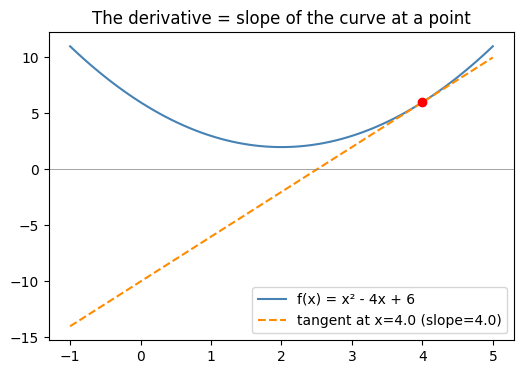

At x=4.0, the slope is 4.0 --> curve is rising steeply, so to REDUCE f(x),
we should move x in the NEGATIVE slope direction (to the left). This exact idea is gradient descent.


In [10]:
def f(x):
    return x**2 - 4*x + 6   # a simple bowl-shaped cost function

def f_prime(x):
    return 2*x - 4          # the derivative (slope) of f, worked out analytically

xs = np.linspace(-1, 5, 100)
ys = f(xs)

point = 4.0
slope = f_prime(point)
tangent = f(point) + slope * (xs - point)   # tangent line at that point

plt.figure(figsize=(6, 4))
plt.plot(xs, ys, label='f(x) = x² - 4x + 6', color='steelblue')
plt.plot(xs, tangent, '--', label=f'tangent at x={point} (slope={slope})', color='darkorange')
plt.scatter([point], [f(point)], color='red', zorder=5)
plt.axhline(0, color='gray', lw=0.5)
plt.title('The derivative = slope of the curve at a point')
plt.legend()
plt.savefig('images/derivative.png', dpi=110, bbox_inches='tight')
plt.show()

print(f"At x={point}, the slope is {slope} --> curve is rising steeply, so to REDUCE f(x),")
print("we should move x in the NEGATIVE slope direction (to the left). This exact idea is gradient descent.")


## 6. Gradient descent — how a model actually "learns"

"Training" a model means: start with random weights, measure how wrong the predictions are (the
**cost**), compute the gradient (which way is uphill), then take a small step in the *opposite*
direction (downhill). Repeat until the cost stops shrinking.

Below, gradient descent finds the minimum of the same bowl-shaped function from Section 5 —
purely by repeatedly asking "which way is downhill?" and stepping that way. No calculus lookup table,
no guessing — just gradients.


In [11]:
def gradient_descent(start_x, learning_rate=0.1, steps=25):
    x = start_x
    history = [x]
    for _ in range(steps):
        grad = f_prime(x)
        x = x - learning_rate * grad   # step downhill
        history.append(x)
    return history

history = gradient_descent(start_x=4.5, learning_rate=0.2, steps=20)

print("Step-by-step x values (watch it converge toward x=2, the true minimum):")
for i, x in enumerate(history):
    print(f"  step {i:2d}: x = {x:.4f}, f(x) = {f(x):.4f}")


Step-by-step x values (watch it converge toward x=2, the true minimum):
  step  0: x = 4.5000, f(x) = 8.2500
  step  1: x = 3.5000, f(x) = 4.2500
  step  2: x = 2.9000, f(x) = 2.8100
  step  3: x = 2.5400, f(x) = 2.2916
  step  4: x = 2.3240, f(x) = 2.1050
  step  5: x = 2.1944, f(x) = 2.0378
  step  6: x = 2.1166, f(x) = 2.0136
  step  7: x = 2.0700, f(x) = 2.0049
  step  8: x = 2.0420, f(x) = 2.0018
  step  9: x = 2.0252, f(x) = 2.0006
  step 10: x = 2.0151, f(x) = 2.0002
  step 11: x = 2.0091, f(x) = 2.0001
  step 12: x = 2.0054, f(x) = 2.0000
  step 13: x = 2.0033, f(x) = 2.0000
  step 14: x = 2.0020, f(x) = 2.0000
  step 15: x = 2.0012, f(x) = 2.0000
  step 16: x = 2.0007, f(x) = 2.0000
  step 17: x = 2.0004, f(x) = 2.0000
  step 18: x = 2.0003, f(x) = 2.0000
  step 19: x = 2.0002, f(x) = 2.0000
  step 20: x = 2.0001, f(x) = 2.0000


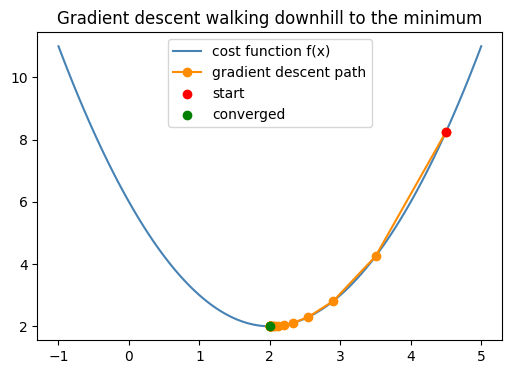

In [12]:
xs = np.linspace(-1, 5, 100)
plt.figure(figsize=(6, 4))
plt.plot(xs, f(xs), color='steelblue', label='cost function f(x)')
hx = np.array(history)
plt.plot(hx, f(hx), 'o-', color='darkorange', label='gradient descent path')
plt.scatter([hx[0]], [f(hx[0])], color='red', label='start', zorder=5)
plt.scatter([hx[-1]], [f(hx[-1])], color='green', label='converged', zorder=5)
plt.title('Gradient descent walking downhill to the minimum')
plt.legend()
plt.savefig('images/gradient_descent.png', dpi=110, bbox_inches='tight')
plt.show()


**Takeaway:** every time a scikit-learn or PyTorch model "trains", this loop is running under the
hood — just with a much more complex cost function and thousands/millions of weights (a big gradient
*vector*) instead of one `x`. The core idea never changes: **compute the gradient, step opposite to it,
repeat.**


## Summary

| Concept | ML use |
|---|---|
| Vectors | A single data row / a set of model weights |
| Dot product | How a linear model scores a data point |
| Matrix multiplication | Scoring an entire dataset at once (vectorization) |
| Conditional probability | Updating beliefs as new evidence/features arrive |
| Distributions | Modeling how real-world values/errors are spread |
| Derivative / gradient | Which direction reduces the model's error |
| Gradient descent | The training loop that "learns" the weights |

**Resources used:** 3Blue1Brown — *Essence of Linear Algebra* & *Essence of Calculus*; StatQuest —
*Gradient Descent, Step-by-Step*.
